In [2]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)



# Rice Type Classification Workbook

This version explains every major step in the pipeline:
1. Load the data
2. Clean and inspect it
3. Prepare features and labels
4. Split into train/validation/test sets correctly
5. Build a PyTorch dataset and dataloaders
6. Train a neural network
7. Evaluate it
8. Predict on one custom input




In [58]:

# ==============================
# 1. Import required libraries
# ==============================

# Core PyTorch libraries
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

# Data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Optional: model summary
from torchsummary import summary

# ------------------------------
# Select device
# ------------------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

# ------------------------------
# Reproducibility
# ------------------------------
# Setting seeds helps get repeatable results.
torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


In [40]:

# ==============================
# 2. Load the dataset
# ==============================

# Update this path if your file is stored elsewhere.
data_df = pd.read_csv('/content/rice-type-classification/riceClassification.csv')

# View first 5 rows
data_df.head()


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [41]:

# ==============================
# 3. Basic cleaning
# ==============================

# Remove rows with missing values, if any
# (This dataset usually has no missing values, but it is a safe practice.)
data_df.dropna(inplace=True)

# Drop the 'id' column because it is just an identifier,
# not a real feature that helps prediction.
data_df.drop(['id'], axis=1, inplace=True)

print('Dataset shape after cleaning:', data_df.shape)


Dataset shape after cleaning: (18185, 11)


In [8]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [43]:

# ==============================
# 4. Inspect the dataset
# ==============================

print('Columns:')
print(list(data_df.columns))
print('Unique values in target column Class:')
print(data_df['Class'].unique())
print('Class counts:')
print(data_df['Class'].value_counts())

# Quick statistical overview
# This helps us understand feature ranges.
data_df.describe().T


Columns:
['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness', 'AspectRation', 'Class']
Unique values in target column Class:
[1 0]
Class counts:
Class
1    9985
0    8200
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Area,18185.0,7036.492989,1467.197150,2522.000000,5962.000000,6660.000000,8423.000000,10210.000000
MajorAxisLength,18185.0,151.680754,12.376402,74.133114,145.675910,153.883750,160.056214,183.211434
MinorAxisLength,18185.0,59.807851,10.061653,34.409894,51.393151,55.724288,70.156593,82.550762
Eccentricity,18185.0,0.915406,0.030575,0.676647,0.891617,0.923259,0.941372,0.966774
ConvexArea,18185.0,7225.817872,1502.006571,2579.000000,6125.000000,6843.000000,8645.000000,11008.000000
EquivDiameter,18185.0,94.132952,9.906250,56.666658,87.126656,92.085696,103.559146,114.016559
Extent,18185.0,0.616653,0.104389,0.383239,0.538530,0.601194,0.695664,0.886573
Perimeter,18185.0,351.606949,29.500620,197.015000,333.990000,353.088000,373.003000,508.511000
Roundness,18185.0,0.707998,0.067310,0.174590,0.650962,0.701941,0.769280,0.904748
AspectRation,18185.0,2.599081,0.434836,1.358128,2.208527,2.602966,2.964101,3.911845


In [44]:

# ==============================
# 5. Save original copy
# ==============================

# We keep a full original copy so we can refer back to the raw ranges later.
original_df = data_df.copy()


In [45]:

# ============================================
# 6. Separate features and label before scaling
# ============================================

# Features = all columns except 'Class'
feature_columns = [col for col in data_df.columns if col != 'Class']

# Create a separate feature dataframe
X_df = data_df[feature_columns].copy()

# Label / target column
y = data_df['Class'].astype(np.float32).values

print('Feature columns:', feature_columns)
print('Number of features:', len(feature_columns))


Feature columns: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness', 'AspectRation']
Number of features: 10


In [46]:

# =============================================
# 7. Normalize features using max-abs scaling
# =============================================


# Here we scale only the feature columns.

# Store max absolute values for each feature.
# We will reuse them later for custom prediction.
feature_max = X_df.abs().max()

# Apply scaling: value / max_abs_value
X_scaled_df = X_df / feature_max

# Convert to NumPy arrays for PyTorch
X = X_scaled_df.values.astype(np.float32)

# Preview scaled features
X_scaled_df.head()


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007


In [47]:

# =====================================
# 8. Split into train / val / test sets
# =====================================


# Correct approach:
# Step 1 -> split into train and temp
# Step 2 -> split temp into validation and test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)


Train shape: (12729, 10)
Validation shape: (2728, 10)
Test shape: (2728, 10)


In [48]:

# ==============================
# 9. Create custom dataset class
# ==============================

class CustomDataset(Dataset):
    def __init__(self, X, y):
        # Keep tensors on CPU here.
        # We will move each batch to GPU/CPU inside the training loop.
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


In [49]:

# ====================================
# 10. Create dataset objects and loaders
# ====================================

training_data = CustomDataset(X_train, y_train)
validation_data = CustomDataset(X_val, y_val)
testing_data = CustomDataset(X_test, y_test)

train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=32, shuffle=False)
testing_dataloader = DataLoader(testing_data, batch_size=32, shuffle=False)

# Quick batch check
for X_batch, y_batch in train_dataloader:
    print('Batch feature shape:', X_batch.shape)
    print('Batch label shape:', y_batch.shape)
    break


Batch feature shape: torch.Size([32, 10])
Batch label shape: torch.Size([32])


In [50]:

# ==============================
# 11. Build the neural network
# ==============================

HIDDEN_NEURONS = 16

class MyModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Layer 1: input -> hidden
        self.input_layer = nn.Linear(input_dim, HIDDEN_NEURONS)

        # Non-linearity helps the model learn more complex patterns.
        self.relu = nn.ReLU()

        # Layer 2: hidden -> output
        # Output is 1 because this is binary classification.
        self.output_layer = nn.Linear(HIDDEN_NEURONS, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)

        # NOTE:
        # We do NOT apply sigmoid here because we are using
        # BCEWithLogitsLoss, which already handles it internally.
        return x

model = MyModel(input_dim=X.shape[1]).to(device)
model


MyModel(
  (input_layer): Linear(in_features=10, out_features=16, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
)

In [27]:
summary(model,((X.shape[1],)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [51]:

# ==============================
# 12. Show model summary
# ==============================

summary(model, (X.shape[1],))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             176
              ReLU-2                   [-1, 16]               0
            Linear-3                    [-1, 1]              17
Total params: 193
Trainable params: 193
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [52]:

# ========================================
# 13. Define loss function and optimizer
# ========================================

# BCEWithLogitsLoss is better than Sigmoid + BCELoss
# because it is numerically more stable.
criterion = nn.BCEWithLogitsLoss()

# Adam optimizer updates weights during training
optimizer = Adam(model.parameters(), lr=1e-3)


In [53]:

# ========================================
# 14. Training loop with validation tracking
# ========================================

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10

for epoch in range(epochs):
    # Track totals for this epoch
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    # ------------------------------
    # Training phase
    # ------------------------------
    model.train()

    for inputs, labels in train_dataloader:
        # Move batch to device
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Reset gradients from previous step
        optimizer.zero_grad()

        # Forward pass
        logits = model(inputs).squeeze(1)

        # Compute loss
        batch_loss = criterion(logits, labels)
        total_loss_train += batch_loss.item()

        # Convert logits -> probabilities -> 0/1 predictions
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        # Count correct predictions
        acc = (preds == labels).sum().item()
        total_acc_train += acc

        # Backpropagation
        batch_loss.backward()
        optimizer.step()

    # ------------------------------
    # Validation phase
    # ------------------------------
    model.eval()

    with torch.no_grad():
        for inputs, labels in validation_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs).squeeze(1)
            batch_loss = criterion(logits, labels)
            total_loss_val += batch_loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            acc = (preds == labels).sum().item()
            total_acc_val += acc

    # Average loss and accuracy for plotting
    train_loss = total_loss_train / len(train_dataloader)
    val_loss = total_loss_val / len(validation_dataloader)
    train_acc = total_acc_train / len(training_data) * 100
    val_acc = total_acc_val / len(validation_data) * 100

    total_loss_train_plot.append(round(train_loss, 4))
    total_loss_validation_plot.append(round(val_loss, 4))
    total_acc_train_plot.append(round(train_acc, 4))
    total_acc_validation_plot.append(round(val_acc, 4))

    print(
        f'Epoch {epoch + 1:02d} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc:.2f}% | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val Acc: {val_acc:.2f}%'
    )


Epoch 01 | Train Loss: 0.6234 | Train Acc: 78.09% | Val Loss: 0.5018 | Val Acc: 97.76%
Epoch 02 | Train Loss: 0.3569 | Train Acc: 98.07% | Val Loss: 0.2346 | Val Acc: 98.53%
Epoch 03 | Train Loss: 0.1743 | Train Acc: 98.29% | Val Loss: 0.1292 | Val Acc: 98.61%
Epoch 04 | Train Loss: 0.1079 | Train Acc: 98.33% | Val Loss: 0.0892 | Val Acc: 98.64%
Epoch 05 | Train Loss: 0.0805 | Train Acc: 98.41% | Val Loss: 0.0713 | Val Acc: 98.90%
Epoch 06 | Train Loss: 0.0668 | Train Acc: 98.46% | Val Loss: 0.0618 | Val Acc: 98.50%
Epoch 07 | Train Loss: 0.0588 | Train Acc: 98.45% | Val Loss: 0.0538 | Val Acc: 98.86%
Epoch 08 | Train Loss: 0.0538 | Train Acc: 98.50% | Val Loss: 0.0499 | Val Acc: 98.94%
Epoch 09 | Train Loss: 0.0505 | Train Acc: 98.57% | Val Loss: 0.0470 | Val Acc: 98.86%
Epoch 10 | Train Loss: 0.0481 | Train Acc: 98.50% | Val Loss: 0.0449 | Val Acc: 98.94%


In [54]:

# ==============================
# 15. Evaluate on the test set
# ==============================

model.eval()

total_loss_test = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testing_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs).squeeze(1)
        batch_loss = criterion(logits, labels)
        total_loss_test += batch_loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds) * 100
print('Test Accuracy:', round(test_accuracy, 4), '%')


Test Accuracy: 99.0103 %


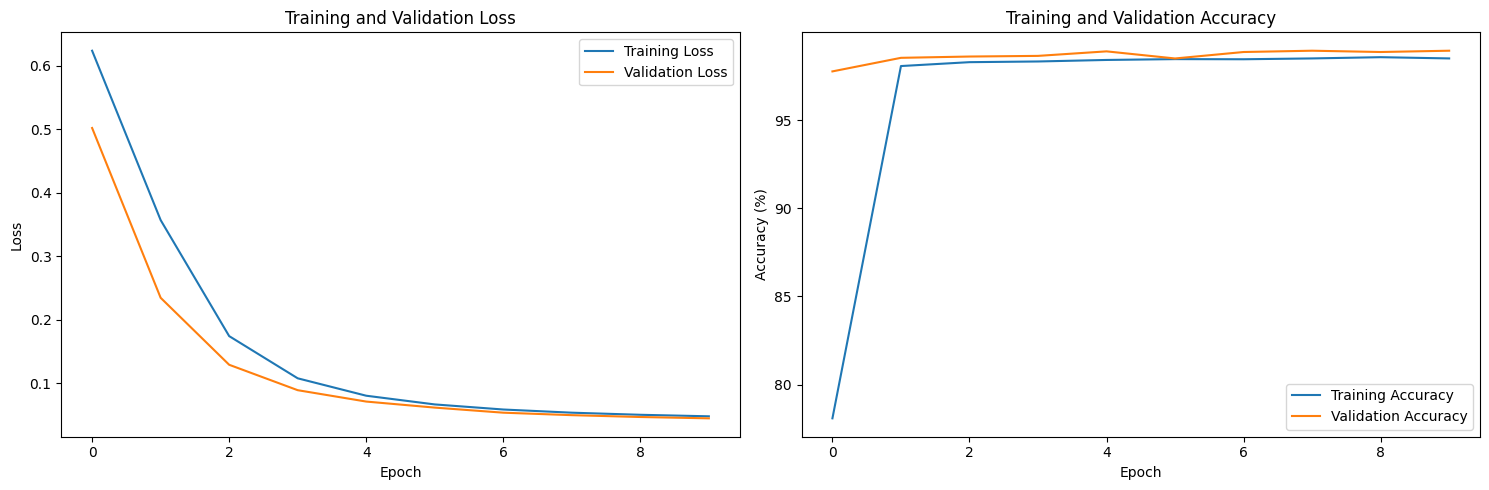

In [55]:

# ==============================
# 16. Plot training history
# ==============================

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Loss curves
axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Accuracy curves
axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()

plt.tight_layout()
plt.show()


In [56]:

# =============================================
# 18. Check raw feature ranges before predicting
# =============================================

# This is very important.
# We should inspect the actual min/max values in the dataset
# before creating a manual input.
range_df = pd.DataFrame({
    'min': original_df[feature_columns].min(),
    'max': original_df[feature_columns].max(),
    'mean': original_df[feature_columns].mean()
})

range_df


,min,max,mean
Area,2522.000000,10210.000000,7036.492989
MajorAxisLength,74.133114,183.211434,151.680754
MinorAxisLength,34.409894,82.550762,59.807851
Eccentricity,0.676647,0.966774,0.915406
ConvexArea,2579.000000,11008.000000,7225.817872
EquivDiameter,56.666658,114.016559,94.132952
Extent,0.383239,0.886573,0.616653
Perimeter,197.015000,508.511000,351.606949
Roundness,0.174590,0.904748,0.707998
AspectRation,1.358128,3.911845,2.599081


In [57]:

# =============================================
# 19. Example custom input for prediction
# =============================================

# IMPORTANT:
# Use values that are realistic and in the same scale as the dataset.
# Below I am using an actual-like sample structure.

raw_input = {
    'Area': 4537,
    'MajorAxisLength': 92.229316,
    'MinorAxisLength': 64.012769,
    'Eccentricity': 0.720137,
    'ConvexArea': 4664,
    'EquivDiameter': 76.004525,
    'Extent': 0.783472,
    'Perimeter': 273.085,
    'Roundness': 0.764510,
    'AspectRation': 1.440796
}

# Convert to DataFrame with correct column order
raw_input_df = pd.DataFrame([raw_input])[feature_columns]

# Apply the SAME scaling used during training
scaled_input_df = raw_input_df / feature_max

# Convert to tensor
input_data = torch.tensor(scaled_input_df.values, dtype=torch.float32).to(device)

# Inference
model.eval()
with torch.no_grad():
    logits = model(input_data).squeeze(1)
    probability = torch.sigmoid(logits).item()
    predicted_class = int(probability >= 0.5)

print('Predicted probability:', round(probability, 4))
print('Predicted class:', predicted_class)


Predicted probability: 0.0337
Predicted class: 0
